In [77]:
import numpy as np
import pandas as pd
from catboost import Pool, CatBoostRegressor
import matplotlib.pyplot as plt

In [78]:
def z_normalization(x: np.array):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    result = (x - mean) / (std + 1e-8)
    return result

def create_seq(x: np.array, y: np.array):
    n = 12
    horizon = 10
    result_x = []
    res_y = []
    for i in range(x.shape[0] - n - horizon):
        result_x.append(x[i:i+n, :].tolist())
        res_y.append(y[i+n+horizon])
    return np.array(result_x), np.array(res_y)

def prepare_target(y_raw: np.array):
    horizon = 10
    y = []
    for i in range(y_raw.shape[0] - horizon):
        diff = np.log(y_raw[i + horizon]) - np.log(y_raw[i])
        y.append(diff)
    
    return np.array(y)

def prepare_prediction(current_gdp, prediction):
    gdp = current_gdp * np.exp(prediction)
    return gdp

In [79]:
import os

path = r"C:\Users\User\Documents\parser\vic2-save\model\data"
directory = os.listdir(path)

In [ ]:
datasets = []

for file in directory:
    if file == "NET_2.csv":
        continue
    if file == "FRA_1.csv":
        data4 = pd.read_csv(os.path.join(path, file))
    else:
        datasets.append(pd.read_csv(os.path.join(path, file)))

gdp_plot = []
def prepare_country_data(df):
    global gdp_plot
    gdp = df["gdp"].values
    gdp_plot.extend(gdp[12+4:])
    bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
    for col in bad_cols:
        if col in df.columns:
            df = df.drop([col], axis=1)
    x = df.values[:]
    return create_seq(x, gdp)


seq_X = []
seqs_y = []

for df in datasets:
    x_s, y_s = prepare_country_data(df)

    seq_X.append(x_s)
    seqs_y.append(y_s)


X = np.concatenate(seq_X, axis=0)[:-4]
y_raw = np.concatenate(seqs_y, axis=0)


X_val, y_val_raw = prepare_country_data(data4)
X_val = X_val[:-4]

y = prepare_target(y_raw)
y_val = prepare_target(y_val_raw)

# X_train_flat = z_normalization(X.reshape(X.shape[0], -1))
# X_val_flat = z_normalization(X_val.reshape(X_val.shape[0], -1))
X_train_flat = X.reshape(X.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

In [81]:
print(y.shape)
print(X_train_flat.shape)
X_val_flat.shape

(3452,)
(3452, 372)


(108, 372)

In [82]:
y

array([ 0.02841331,  0.03809674,  0.04953647, ..., -0.05650113,
       -0.02013245,  0.14073071], shape=(3452,))

In [83]:
model = CatBoostRegressor(
    iterations=6000,
    learning_rate=5e-3,
    depth=6,
    early_stopping_rounds=100,
    verbose=50,
    loss_function='RMSE',
    l2_leaf_reg = 0.5,
)

train_pool = Pool(X_train_flat, y)
validation_pool = Pool(X_val_flat, y_val)

model.fit(train_pool, eval_set=validation_pool)

0:	learn: 0.5227962	test: 0.2698819	best: 0.2698819 (0)	total: 26.2ms	remaining: 2m 37s
50:	learn: 0.4847926	test: 0.2712149	best: 0.2697129 (3)	total: 1.25s	remaining: 2m 26s
100:	learn: 0.4558254	test: 0.2775157	best: 0.2697129 (3)	total: 2.4s	remaining: 2m 20s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2697128602
bestIteration = 3

Shrink model to first 4 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=100, iterations=6000, l2_leaf_reg=0.5, learning_rate=0.005, loss_function='RMSE', verbose=50)

In [84]:
data_train = pd.read_csv("data/FRA_1.csv")
y_np_t = data_train["gdp"].values
X_np_t = data_train.drop(["date", "gdp", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values

# X_z_t = z_normalization(X_np_t)
X_z_t = X_np_t

X_test, real_gdp = create_seq(X_z_t, y_np_t)

prediction = model.predict(X_test.reshape([X_test.shape[0], -1]))


true_pred = []
for i in range(real_gdp.shape[0]):
    curr = real_gdp[i]
    pred = prediction[i]
    true_pred.append(prepare_prediction(curr, pred))

true_pred = np.array(true_pred)


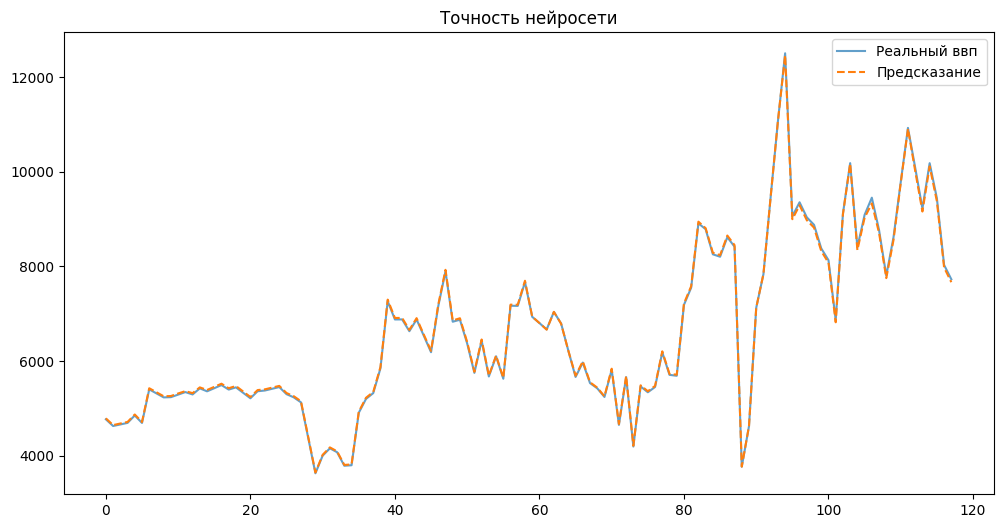

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(real_gdp, label='Реальный ввп', alpha=0.7)
plt.plot(true_pred, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()

In [86]:
importance = model.get_feature_importance()

temp = data4

bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
for col in bad_cols:
    if col in temp.columns:
        temp = temp.drop([col], axis=1)
names = temp.columns.tolist()

fancy = []
for name in names:
    for n in range(12):
        fancy.append(f"{name} в {(12 - n) / 2} год данных")


df = pd.DataFrame(
    {
        "features": fancy,
        "importances": importance,
    }
).sort_values(by = "importances", ascending=False)

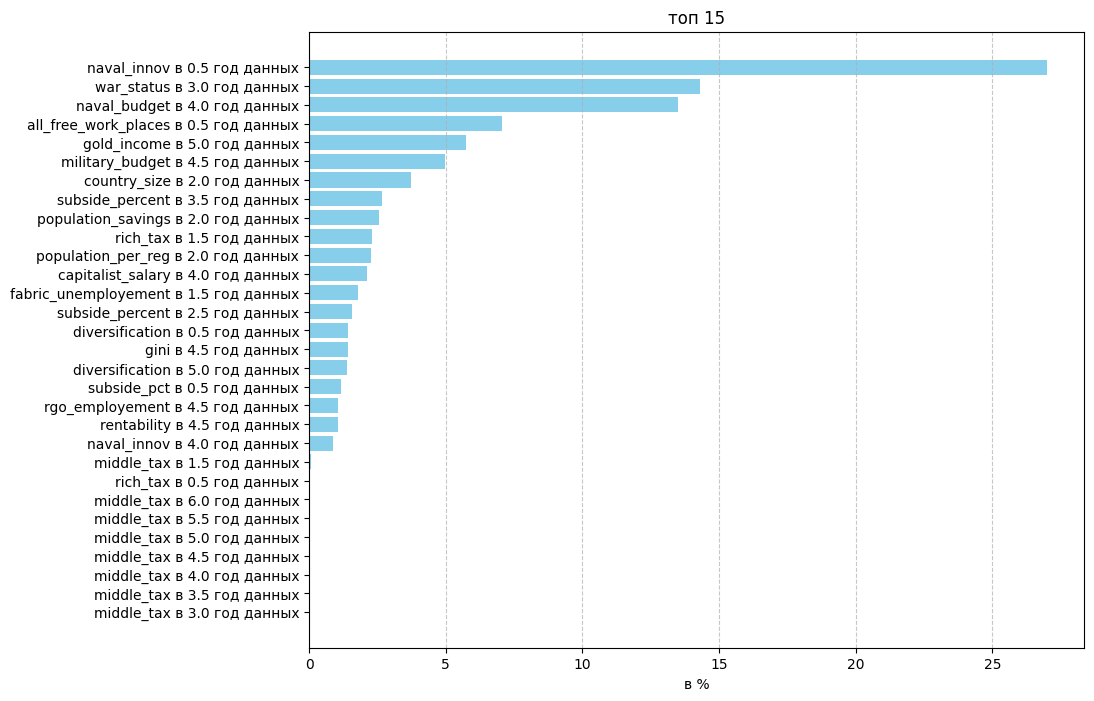

In [87]:
plt.figure(figsize=(10, 8))

top = df.head(30)

plt.barh(top["features"], top["importances"], color='skyblue')
plt.xlabel('в %')
plt.title('топ 15')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

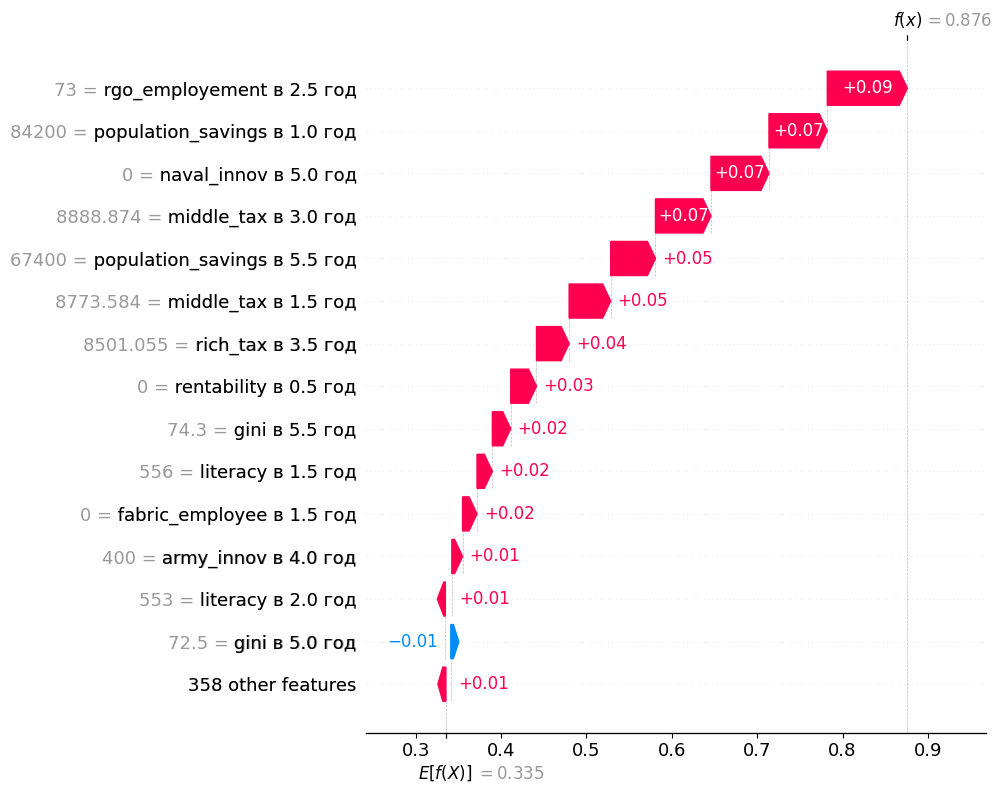

In [88]:
import shap

fancy_shap = []
for n in range(12): 
    years = (12 - n) / 2
    for name in names:
        fancy_shap.append(f"{name} в {years} год")

explainer = shap.Explainer(model)
shap_values = explainer(X_train_flat)
shap_values.feature_names = fancy_shap

shap.plots.waterfall(shap_values[1000] * 100, max_display=15)

In [89]:
fname = "export_models/model"
model.save_model(fname,
                format="cbm",
                export_parameters=None,
                pool=None)